<>:97: SyntaxWarning: invalid escape sequence '\s'
<>:98: SyntaxWarning: invalid escape sequence '\s'
<>:97: SyntaxWarning: invalid escape sequence '\s'
<>:98: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_460/4255037171.py:97: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_xlabel('Observed $\sigma$ (km/s)')
/tmp/ipykernel_460/4255037171.py:98: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_ylabel('WILL RG Predicted $\sigma$ (km/s)')


-----------------------------------------------------------------
WILL RG AB INITIO PREDICTIONS (Zero Free Parameters)
    LensID  sigma_obs  sigma_pred  theta_E_obs  theta_E_pred
J0037-0942        279      282.11         1.53          1.49
J0216-0813        333      286.12         1.16          0.78
J0737+3216        323      285.34         1.00          0.95
J0946+1006        287      282.96         1.43          1.37
J0956+5100        334      296.55         1.33          1.15
J1250+0523        252      268.53         1.13          1.37
J1430+4105        322      292.07         1.52          1.14
J1627-0053        290      298.59         1.23          1.46
-----------------------------------------------------------------
Kinematics Mean Absolute Error: 23.02 km/s
Lensing Mean Absolute Error:    0.195 arcsec
-----------------------------------------------------------------


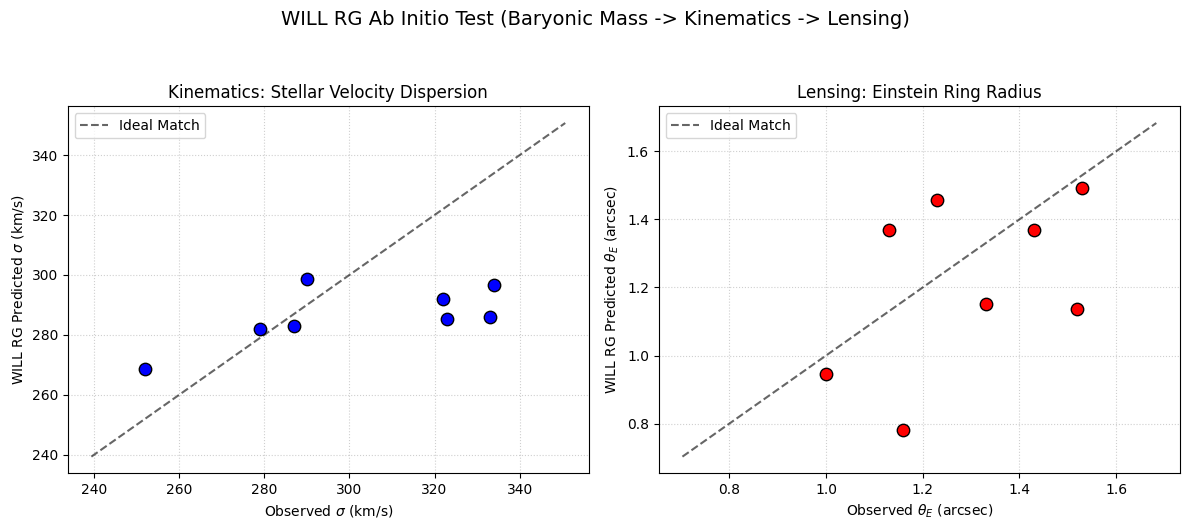

In [3]:
import pandas as pd
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

# ==========================================
# 1. WILL RG CONSTANTS & EXACT COSMOLOGY
# ==========================================
H0 = 68.15             # km/s/Mpc (Derived from CMB Temp and alpha)
Omega_m = 1/3          # Kinetic geometric weight
Omega_L = 2/3          # Structural tension geometric weight
c_m_s = 299792458.0    # m/s
c_kms = 299792.458     # km/s
G = 6.6743e-11         # m^3/kg/s^2
M_sun = 1.9884e30      # kg
Mpc_to_m = 3.08567758e22

# Derived Machian Acceleration Scale for Galaxies
a_k = c_m_s * (H0 * 1000 / Mpc_to_m) / (3 * np.pi)

def E(z):
    return np.sqrt(Omega_m * (1+z)**3 + Omega_L)

def D_A_Mpc(z1, z2):
    if z1 >= z2: return 0.0
    res, _ = quad(lambda z: 1.0 / E(z), z1, z2)
    return (c_kms / (H0 * (1+z2))) * res

# ==========================================
# 2. REAL EMPIRICAL DATA (Auger et al. 2009)
# ==========================================
real_data = [
    {'LensID': 'J0037-0942', 'z_L': 0.1954, 'z_S': 0.6322, 'sigma_obs': 279, 'theta_E_obs': 1.53, 'logM_S': 11.50, 'Re_arcsec': 1.70},
    {'LensID': 'J0216-0813', 'z_L': 0.3317, 'z_S': 0.5235, 'sigma_obs': 333, 'theta_E_obs': 1.16, 'logM_S': 11.74, 'Re_arcsec': 2.15},
    {'LensID': 'J0737+3216', 'z_L': 0.3223, 'z_S': 0.5812, 'sigma_obs': 323, 'theta_E_obs': 1.00, 'logM_S': 11.69, 'Re_arcsec': 1.92},
    {'LensID': 'J0946+1006', 'z_L': 0.2219, 'z_S': 0.6085, 'sigma_obs': 287, 'theta_E_obs': 1.43, 'logM_S': 11.48, 'Re_arcsec': 1.45},
    {'LensID': 'J0956+5100', 'z_L': 0.2405, 'z_S': 0.4700, 'sigma_obs': 334, 'theta_E_obs': 1.33, 'logM_S': 11.64, 'Re_arcsec': 1.85},
    {'LensID': 'J1250+0523', 'z_L': 0.2318, 'z_S': 0.7950, 'sigma_obs': 252, 'theta_E_obs': 1.13, 'logM_S': 11.36, 'Re_arcsec': 1.17},
    {'LensID': 'J1430+4105', 'z_L': 0.2850, 'z_S': 0.5753, 'sigma_obs': 322, 'theta_E_obs': 1.52, 'logM_S': 11.75, 'Re_arcsec': 2.31},
    {'LensID': 'J1627-0053', 'z_L': 0.2076, 'z_S': 0.5241, 'sigma_obs': 290, 'theta_E_obs': 1.23, 'logM_S': 11.50, 'Re_arcsec': 1.40}
]
df = pd.DataFrame(real_data)

# ==========================================
# 3. AB INITIO PREDICTION (Mass -> Kinematics -> Lensing)
# ==========================================
def predict_ab_initio(row):
    DL_mpc = D_A_Mpc(0, row['z_L'])
    DS_mpc = D_A_Mpc(0, row['z_S'])
    DLS_mpc = D_A_Mpc(row['z_L'], row['z_S'])

    # Physical Re in meters
    Re_m = row['Re_arcsec'] * (np.pi / 180 / 3600) * DL_mpc * Mpc_to_m
    M_star = (10**row['logM_S']) * M_sun # Baryonic Mass

    # A. Kinematics (Isothermal Approximation at Re)
    sigma_bar_sq = (G * M_star) / (4 * Re_m) # Pure Newtonian Baryons

    # WILL RG Horizon Interference
    interference = np.sqrt(sigma_bar_sq * (a_k * Re_m / 2))
    sigma_pred_sq = sigma_bar_sq + interference
    sigma_pred = np.sqrt(sigma_pred_sq)

    # B. Lensing (WILL RG Exact Projection)
    kappa_2d_sq = 2 * np.pi * (sigma_pred / c_m_s)**2
    ratio = kappa_2d_sq / (1.0 - kappa_2d_sq)
    theta_E_rad = 2.0 * (DLS_mpc / DS_mpc) * np.arcsin(ratio)
    theta_E_pred = theta_E_rad * (180.0 / np.pi) * 3600.0

    return pd.Series({'sigma_pred': sigma_pred/1000, 'theta_E_pred': theta_E_pred})

df[['sigma_pred', 'theta_E_pred']] = df.apply(predict_ab_initio, axis=1)

# Metrics
mae_sig = abs(df['sigma_pred'] - df['sigma_obs']).mean()
mae_theta = abs(df['theta_E_pred'] - df['theta_E_obs']).mean()

print("-" * 65)
print("WILL RG AB INITIO PREDICTIONS (Zero Free Parameters)")
print(df[['LensID', 'sigma_obs', 'sigma_pred', 'theta_E_obs', 'theta_E_pred']].round(2).to_string(index=False))
print("-" * 65)
print(f"Kinematics Mean Absolute Error: {mae_sig:.2f} km/s")
print(f"Lensing Mean Absolute Error:    {mae_theta:.3f} arcsec")
print("-" * 65)

# ==========================================
# 4. VISUALIZATION
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Kinematics
ax1.scatter(df['sigma_obs'], df['sigma_pred'], color='blue', edgecolor='black', s=80, zorder=5)
min_sig = min(df['sigma_obs'].min(), df['sigma_pred'].min()) * 0.95
max_sig = max(df['sigma_obs'].max(), df['sigma_pred'].max()) * 1.05
ax1.plot([min_sig, max_sig], [min_sig, max_sig], 'k--', alpha=0.6, label='Ideal Match')
ax1.set_title('Kinematics: Stellar Velocity Dispersion', fontsize=12)
ax1.set_xlabel('Observed $\sigma$ (km/s)')
ax1.set_ylabel('WILL RG Predicted $\sigma$ (km/s)')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# Plot 2: Lensing
ax2.scatter(df['theta_E_obs'], df['theta_E_pred'], color='red', edgecolor='black', s=80, zorder=5)
min_th = min(df['theta_E_obs'].min(), df['theta_E_pred'].min()) * 0.9
max_th = max(df['theta_E_obs'].max(), df['theta_E_pred'].max()) * 1.1
ax2.plot([min_th, max_th], [min_th, max_th], 'k--', alpha=0.6, label='Ideal Match')
ax2.set_title('Lensing: Einstein Ring Radius', fontsize=12)
ax2.set_xlabel('Observed $\\theta_E$ (arcsec)')
ax2.set_ylabel('WILL RG Predicted $\\theta_E$ (arcsec)')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.suptitle('WILL RG Ab Initio Test (Baryonic Mass -> Kinematics -> Lensing)', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()